In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.linalg import toeplitz
import seaborn as sns
import pandas as pd

In [ ]:
np.random.seed(0)

In [ ]:
sns.set_theme(style="whitegrid")

D = 20
W_STAR = np.ones((D, 1)) # True parameter vector w*

N_VALUES = [50, 200, 1000] # Training sample sizes
RHO_VALUES = [0.0, 0.5, 0.9]      # Feature correlation values
SIGMA_SQ_VALUES = [0.01, 1.0, 5.0]      # Noise variance values

NUM_TRIALS = 25
N_TEST = 10000

In [ ]:
def create_covariance_matrix(d, rho):
    indices = np.arange(d)
    first_row = rho ** indices
    return toeplitz(first_row)

#### Run the full simulation across all parameter combinations.

In [ ]:
results = {rho: {ssq: {} for ssq in SIGMA_SQ_VALUES} for rho in RHO_VALUES}

for rho in RHO_VALUES:
    print(f"\nProcessing Correlation rho = {rho}...")
    cov_matrix = create_covariance_matrix(D, rho)
    mean_vec = np.zeros(D)

    # Generate a large, fixed test set for this rho
    X_test = np.random.multivariate_normal(mean_vec, cov_matrix, size=N_TEST)

    for sigma_sq in SIGMA_SQ_VALUES:
        print(f"  Noise Variance sigma^2 = {sigma_sq}:")

        # Generate test labels once for this sigma_sq
        epsilon_test = np.random.normal(0, np.sqrt(sigma_sq), size=(N_TEST, 1))
        y_test = X_test @ W_STAR + epsilon_test

        bayes_mse = sigma_sq

        for n in N_VALUES:
            trial_mses = []
            for _ in range(NUM_TRIALS):
                # Generate features X from a multivariate Gaussian
                X_train = np.random.multivariate_normal(mean_vec, cov_matrix, size=n)

                # Generate labels y with noise
                epsilon_train = np.random.normal(0, np.sqrt(sigma_sq), size=(n, 1))
                y_train = X_train @ W_STAR + epsilon_train

                # Fit OLS Linear Regression model
                model = LinearRegression(fit_intercept=False) # Data is zero-mean
                model.fit(X_train, y_train)

                # Evaluate on the large test set
                y_pred = model.predict(X_test)
                model_mse = mean_squared_error(y_test, y_pred)
                trial_mses.append(model_mse)

            # Calculate the average excess MSE over all trials
            avg_model_mse = np.mean(trial_mses)
            excess_mse = avg_model_mse - bayes_mse
            results[rho][sigma_sq][n] = excess_mse

        print(f"    Completed for all n.")


Processing Correlation rho = 0.0...
  Noise Variance sigma^2 = 0.01:
    Completed for all n.
  Noise Variance sigma^2 = 1.0:
    Completed for all n.
  Noise Variance sigma^2 = 5.0:
    Completed for all n.

Processing Correlation rho = 0.5...
  Noise Variance sigma^2 = 0.01:
    Completed for all n.
  Noise Variance sigma^2 = 1.0:
    Completed for all n.
  Noise Variance sigma^2 = 5.0:
    Completed for all n.

Processing Correlation rho = 0.9...
  Noise Variance sigma^2 = 0.01:
    Completed for all n.
  Noise Variance sigma^2 = 1.0:
    Completed for all n.
  Noise Variance sigma^2 = 5.0:
    Completed for all n.


#### Generates plots to visualize the simulation results.
#### Plot 1: Excess MSE vs. Sample Size (n)

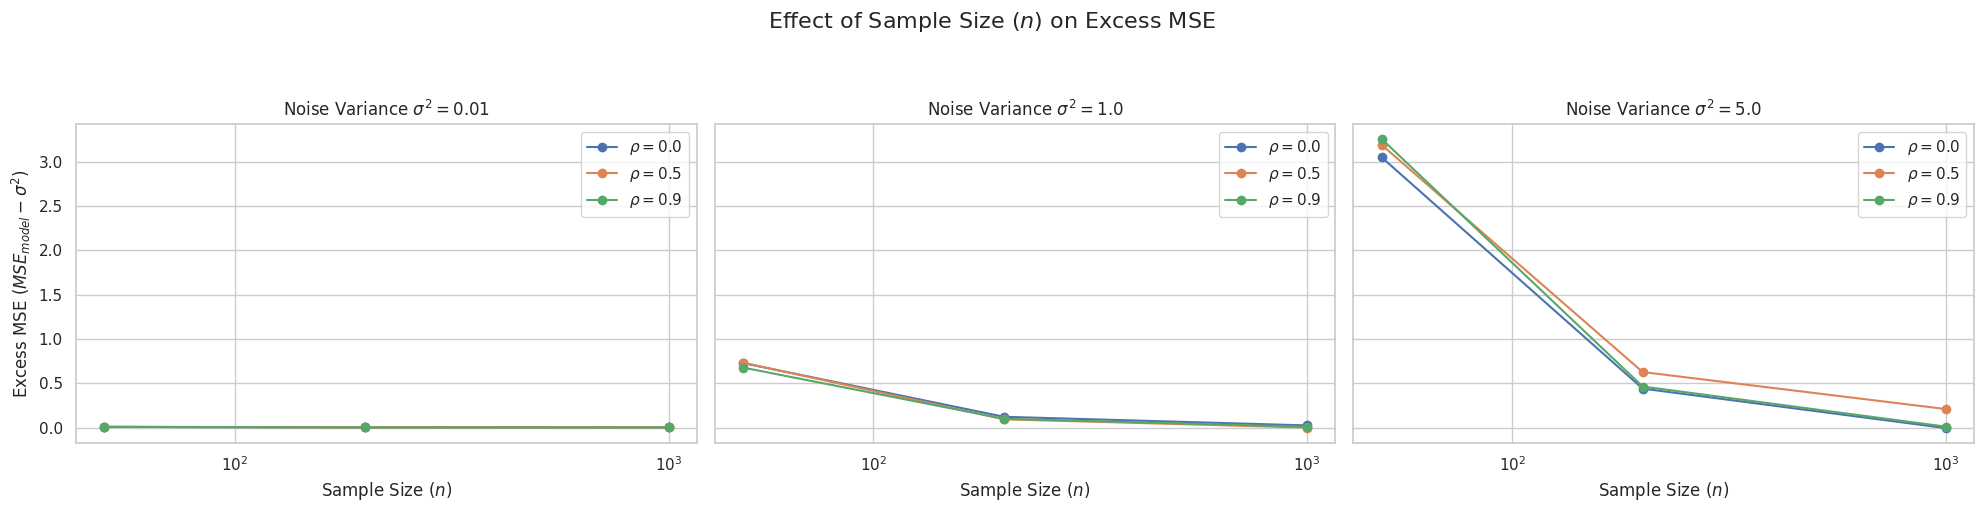

In [ ]:
fig1, axes1 = plt.subplots(1, len(SIGMA_SQ_VALUES), figsize=(20, 5), sharey=True)
fig1.suptitle('Effect of Sample Size ($n$) on Excess MSE', fontsize=16, y=1.02)

for i, sigma_sq in enumerate(SIGMA_SQ_VALUES):
    ax = axes1[i]
    for rho in RHO_VALUES:
        # Extract n values and corresponding excess MSEs
        n_vals = sorted(results[rho][sigma_sq].keys())
        mse_vals = [results[rho][sigma_sq][n] for n in n_vals]
        ax.plot(n_vals, mse_vals, marker='o', linestyle='-', label=f'$\\rho={rho}$')

    ax.set_title(f'Noise Variance $\\sigma^2 = {sigma_sq}$')
    ax.set_xlabel('Sample Size ($n$)')
    ax.set_xscale('log')
    ax.legend()
    if i == 0:
        ax.set_ylabel('Excess MSE ($MSE_{model} - \\sigma^2$)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Plot 2: Excess MSE vs. Feature Correlation (rho)

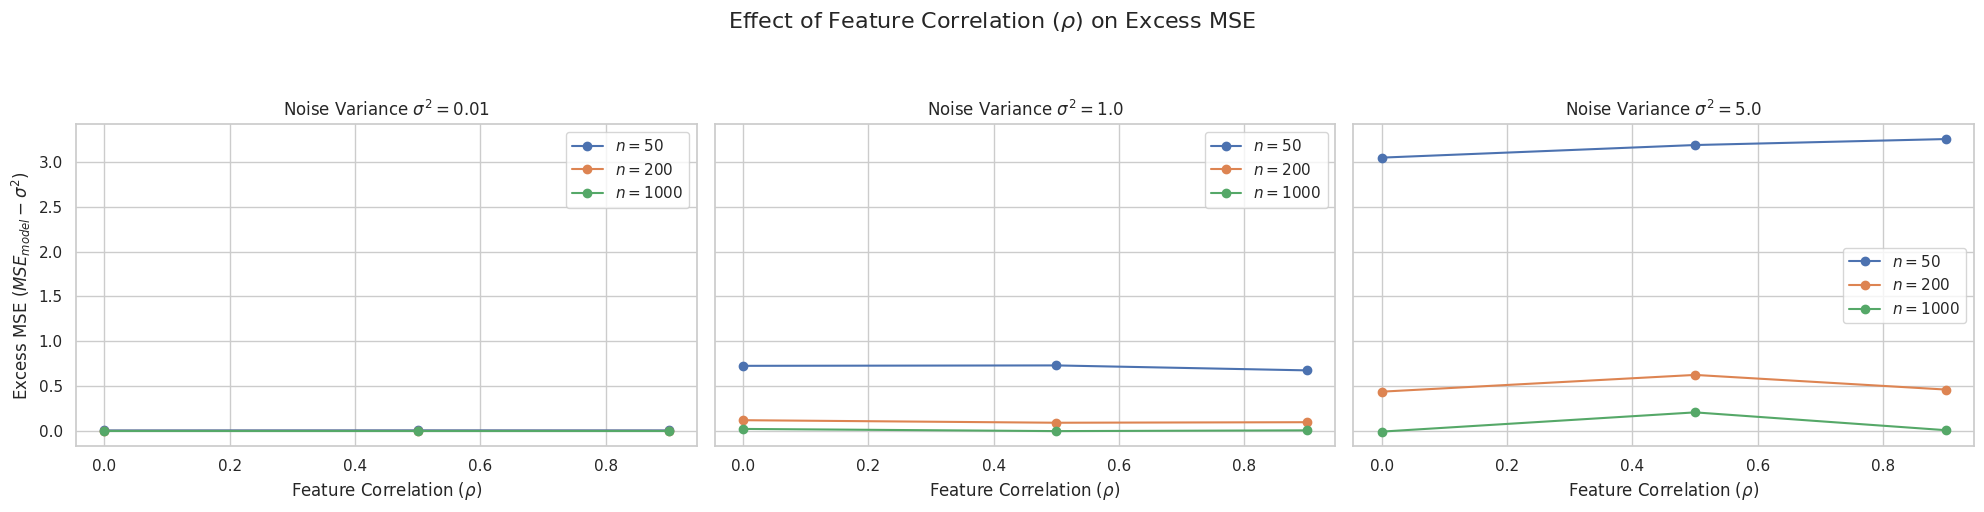

In [ ]:
fig2, axes2 = plt.subplots(1, len(SIGMA_SQ_VALUES), figsize=(20, 5), sharey=True)
fig2.suptitle('Effect of Feature Correlation ($\\rho$) on Excess MSE', fontsize=16, y=1.02)

for i, sigma_sq in enumerate(SIGMA_SQ_VALUES):
    ax = axes2[i]
    for n in N_VALUES:
        rho_vals = sorted(results.keys())
        mse_vals = [results[rho][sigma_sq][n] for rho in rho_vals]
        ax.plot(rho_vals, mse_vals, marker='o', linestyle='-', label=f'$n={n}$')

    ax.set_title(f'Noise Variance $\\sigma^2 = {sigma_sq}$')
    ax.set_xlabel('Feature Correlation ($\\rho$)')
    ax.legend()
    if i == 0:
        ax.set_ylabel('Excess MSE ($MSE_{model} - \\sigma^2$)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Prints the simulation results in a formatted table using pandas.

In [ ]:
records = []
for rho, sigma_data in results.items():
    for sigma_sq, n_data in sigma_data.items():
        for n, excess_mse in n_data.items():
            records.append({
                'rho': rho,
                'sigma^2': sigma_sq,
                'n': n,
                'Excess MSE': excess_mse
            })

if not records:
    print("No results to display.")

else:
    df = pd.DataFrame(records)

    result_table = df.pivot_table(
        index=['rho', 'sigma^2'],
        columns='n',
        values='Excess MSE'
    )

    pd.set_option('display.float_format', '{:.4f}'.format)

    print("\n" + "="*80)
    print("Table: Gap between Achieved MSE and Bayes MSE (Excess MSE)".center(80))
    print("="*80)
    print(result_table)
    print("="*80 + "\n")


           Table: Gap between Achieved MSE and Bayes MSE (Excess MSE)           
n                50     200     1000
rho    sigma^2                      
0.0000 0.0100  0.0070 0.0012  0.0003
       1.0000  0.7269 0.1208  0.0235
       5.0000  3.0480 0.4387 -0.0066
0.5000 0.0100  0.0078 0.0011  0.0002
       1.0000  0.7315 0.0925 -0.0009
       5.0000  3.1884 0.6256  0.2080
0.9000 0.0100  0.0072 0.0012  0.0002
       1.0000  0.6762 0.0985  0.0077
       5.0000  3.2550 0.4623  0.0095



### 1. High Feature Correlation
In general, high feature correlation (multicollinearity) significantly increases estimation error for a small number of samples ($m$). This is because it becomes difficult for the model to isolate the individual contribution of each feature, leading to unstable and high-variance parameter estimates.

***

### 2. Sample Size vs. Bayes MSE
In general, the estimation error may not converge to Bayes MSE. Eg: When data is generated using a quadratic relation, a linear model cannot capture this data irrespective of the sample size.

***

### 3. Correlation vs. Noise ($\sigma^2$)
For a fixed sample size ($m$), increasing the noise variance ($\sigma^2$) makes the impact of correlation less important relative to the total error. As $\sigma^2$ grows, it dominates the total MSE, making the estimation error caused by correlation a proportionally smaller concern.

***

### 4. Achieving Near-Optimal Performance
Near-optimal performance (where empirical MSE approaches the Bayes limit) is best achieved in scenarios with a large sample size ($m$) and low feature correlation ($\rho$).